# 模块 07：卷积神经网络

## 1. 理论背景
卷积通过局部连接和权重共享提取图像特征。相比全连接层，卷积核参数少，并保留空间结构。

## 1.1 实际作用（用途）
- 广泛用于图像分类、目标检测、医学影像、OCR、工业缺陷检测和自动驾驶感知。
- 卷积核学习边缘、纹理、角点和形状等局部模式，再逐层组合成高层语义。
- 权重共享让模型能在不同位置识别同一种模式，适合空间结构数据。

## 2. 数学推导
单通道 2D 卷积输出：

$$Y[i,j]=\sum_m\sum_n X[i+m,j+n]K[m,n]$$

多通道时还需对输入通道求和。padding 控制边界，stride 控制滑动步长。

## 3. 代码思路

本章代码用最小图像例子拆解卷积和池化：

1. `conv2d_single` 先处理 padding，再按 stride 滑动卷积核，对每个局部窗口做逐元素乘积求和。
2. `maxpool2d` 用同样的滑动窗口思想，只是每个窗口保留最大值，用于降采样和保留强响应。
3. 人工构造一个 8x8 竖条图像，让边缘检测卷积核的效果更容易观察。
4. 卷积后接 ReLU 去掉负响应，再做 MaxPool 得到更小的特征图。
5. 验证部分用 PyTorch `conv2d` 对照手写卷积，确认窗口索引、padding 和输出形状正确。

## 4. NumPy 实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

def conv2d_single(x, kernel, padding=0, stride=1):
    x = np.asarray(x, dtype=float)
    k = np.asarray(kernel, dtype=float)
    # padding 会在边缘补 0，使卷积后尺寸更容易控制。
    if padding:
        x = np.pad(x, ((padding, padding), (padding, padding)))
    oh = (x.shape[0] - k.shape[0]) // stride + 1
    ow = (x.shape[1] - k.shape[1]) // stride + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            # patch 是当前卷积核覆盖的局部区域。
            patch = x[i*stride:i*stride+k.shape[0], j*stride:j*stride+k.shape[1]]
            out[i, j] = np.sum(patch * k)
    return out

def maxpool2d(x, size=2, stride=2):
    oh = (x.shape[0] - size) // stride + 1
    ow = (x.shape[1] - size) // stride + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            # MaxPool 保留局部窗口中最强的响应。
            out[i, j] = np.max(x[i*stride:i*stride+size, j*stride:j*stride+size])
    return out

# 构造一个简单 8x8 图像，中间竖条用于演示边缘检测。
image = np.zeros((8, 8)); image[2:6, 3:5] = 1
edge_kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
feature = conv2d_single(image, edge_kernel, padding=1)
# ReLU 去掉负响应，再池化降低空间尺寸。
pooled = maxpool2d(np.maximum(0, feature))
print("卷积输出形状：feature =", feature.shape, "；池化后形状：pooled =", pooled.shape, "。池化会降低空间尺寸并保留局部最大响应。")


卷积输出形状：feature = (8, 8) ；池化后形状：pooled = (4, 4) 。池化会降低空间尺寸并保留局部最大响应。


## 5. 结果验证

In [2]:
try:
    import torch
    # PyTorch conv2d 输入格式是 NCHW：批量、通道、高、宽。
    xt = torch.tensor(image[None, None], dtype=torch.float64)
    kt = torch.tensor(edge_kernel[None, None], dtype=torch.float64)
    yt = torch.nn.functional.conv2d(xt, kt, padding=1)
    assert np.allclose(yt.numpy()[0,0], feature, atol=1e-5)
    print('验证通过：手写 NumPy 卷积与 PyTorch conv2d 输出一致。')
except ImportError:
    print('提示：当前环境未安装 PyTorch；请查看上方 NumPy 卷积与池化输出形状。')


验证通过：手写 NumPy 卷积与 PyTorch conv2d 输出一致。


## 6. 可视化

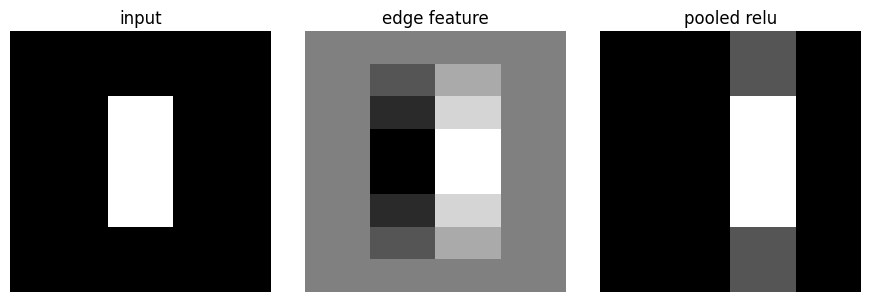

In [3]:
plt.figure(figsize=(9, 3))
# 依次展示原图、卷积边缘响应、ReLU+池化后的特征图。
for idx, (title, arr) in enumerate([('input', image), ('edge feature', feature), ('pooled relu', pooled)], 1):
    plt.subplot(1, 3, idx); plt.imshow(arr, cmap='gray'); plt.title(title); plt.axis('off')
plt.tight_layout(); plt.show()
